## Subset Extraction

In [2]:
import pyarrow.parquet as pq
import pandas as pd

def load_stratified_subset(path, n_per_class=5000, seed=42):
    pf = pq.ParquetFile(path)
    chunks = []

    for batch in pf.iter_batches(batch_size=100_000, columns=["DATA", "TOPIC"]):
        chunk = batch.to_pandas()
        
        # Sample per group, keeping TOPIC column explicitly
        sampled_groups = []
        for topic, group in chunk.groupby("TOPIC"):
            n = min(len(group), 500)
            sampled_groups.append(group.sample(n, random_state=seed))
        
        chunks.append(pd.concat(sampled_groups, ignore_index=True))

    df = pd.concat(chunks, ignore_index=True)

    # Final downsample to n_per_class per topic
    final_groups = []
    for topic, group in df.groupby("TOPIC"):
        n = min(len(group), n_per_class)
        final_groups.append(group.sample(n, random_state=seed))

    return pd.concat(final_groups, ignore_index=True)


subset = load_stratified_subset("D:\IIT Gandhinagar\SRIP 26\Mayank Singh\dataset_10M.parquet", n_per_class=5000)
print(subset["TOPIC"].value_counts())
print(f"Total rows: {len(subset)}")

<>:30: SyntaxWarning: invalid escape sequence '\I'
<>:30: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22960\3698661897.py:30: SyntaxWarning: invalid escape sequence '\I'
  subset = load_stratified_subset("D:\IIT Gandhinagar\SRIP 26\Mayank Singh\dataset_10M.parquet", n_per_class=5000)


TOPIC
adult_content                  5000
art_and_design                 5000
crime_and_law                  5000
education_and_jobs             5000
electronics_and_hardare        5000
entertainment                  5000
fashion_and_beauty             5000
finance_and_business           5000
food_and_dining                5000
games                          5000
health                         5000
history_and_geography          5000
home_and_hobbies               5000
industrial                     5000
literature                     5000
politics                       5000
religion                       5000
science_math_and_technology    5000
social_life                    5000
software                       5000
software_development           5000
sports_and_fitness             5000
transportation                 5000
travel_and_tourism             5000
Name: count, dtype: int64
Total rows: 120000


---
## EDA

In [3]:
import matplotlib.pyplot as plt

# Text length distribution
subset["word_count"] = subset["DATA"].str.split().str.len()
print(subset.groupby("TOPIC")["word_count"].describe()[["mean","50%","max"]])

# Any nulls or empty strings?
print("Nulls:", subset["DATA"].isnull().sum())
print("Empty:", (subset["DATA"].str.strip() == "").sum())

# Sample text per class
for topic, grp in subset.groupby("TOPIC"):
    print(f"\n[{topic}]")
    print(grp["DATA"].iloc[0][:200])

                                  mean    50%       max
TOPIC                                                  
adult_content                 116.1298    1.0   90416.0
art_and_design               1018.0374  189.0  289393.0
crime_and_law                 253.4512   42.0   65484.0
education_and_jobs           1260.4972  367.5   21227.0
electronics_and_hardare       508.2356   88.0  358832.0
entertainment                 301.8536  134.0  341824.0
fashion_and_beauty            906.0868  215.0   65013.0
finance_and_business          319.6452  117.0  153295.0
food_and_dining               425.4928  220.0   42641.0
games                        1158.4514  218.5  818003.0
health                        934.8856  219.0  359617.0
history_and_geography         422.0006  162.0  100357.0
home_and_hobbies              326.6024  442.0   14191.0
industrial                    799.3440  179.0  141266.0
literature                    649.5878  162.0  273058.0
politics                      446.6724  236.0   

---
## TF-IDF + Logistic Reg 

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import time

# ── 1. Split ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    subset["DATA"], subset["TOPIC"],
    test_size=0.2, random_state=42, stratify=subset["TOPIC"]
)

# ── 2. TF-IDF ─────────────────────────────────────────────────────────────────
print("Fitting TF-IDF...")
t0 = time.time()
vectorizer = TfidfVectorizer(
    max_features=100_000,
    sublinear_tf=True,          # log(1+tf) — dampens long-doc dominance
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=3,                   # ignore very rare terms
    strip_accents="unicode",
    analyzer="word",
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f"TF-IDF done in {time.time()-t0:.1f}s  |  shape: {X_train_tfidf.shape}")

# ── 3. Logistic Regression ────────────────────────────────────────────────────
print("\nTraining Logistic Regression...")
t0 = time.time()
clf = LogisticRegression(
    max_iter=1000,
    C=5.0,
    solver="saga",              # fast for large sparse matrices
    n_jobs=-1,
    random_state=42,
)
clf.fit(X_train_tfidf, y_train)
print(f"Training done in {time.time()-t0:.1f}s")

# ── 4. Evaluate ───────────────────────────────────────────────────────────────
y_pred = clf.predict(X_test_tfidf)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, digits=3))

Fitting TF-IDF...
TF-IDF done in 327.3s  |  shape: (96000, 100000)

Training Logistic Regression...


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training done in 316.1s

Accuracy: 0.8301

Per-class report:
                             precision    recall  f1-score   support

              adult_content      0.979     0.913     0.945      1000
             art_and_design      0.771     0.764     0.767      1000
              crime_and_law      0.908     0.876     0.892      1000
         education_and_jobs      0.881     0.843     0.862      1000
    electronics_and_hardare      0.838     0.826     0.832      1000
              entertainment      0.862     0.831     0.846      1000
         fashion_and_beauty      0.793     0.790     0.792      1000
       finance_and_business      0.942     0.878     0.909      1000
            food_and_dining      0.773     0.837     0.804      1000
                      games      0.796     0.790     0.793      1000
                     health      0.835     0.792     0.813      1000
      history_and_geography      0.782     0.767     0.774      1000
           home_and_hobbies      0.973   

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/exp1_confusion_matrix.png'

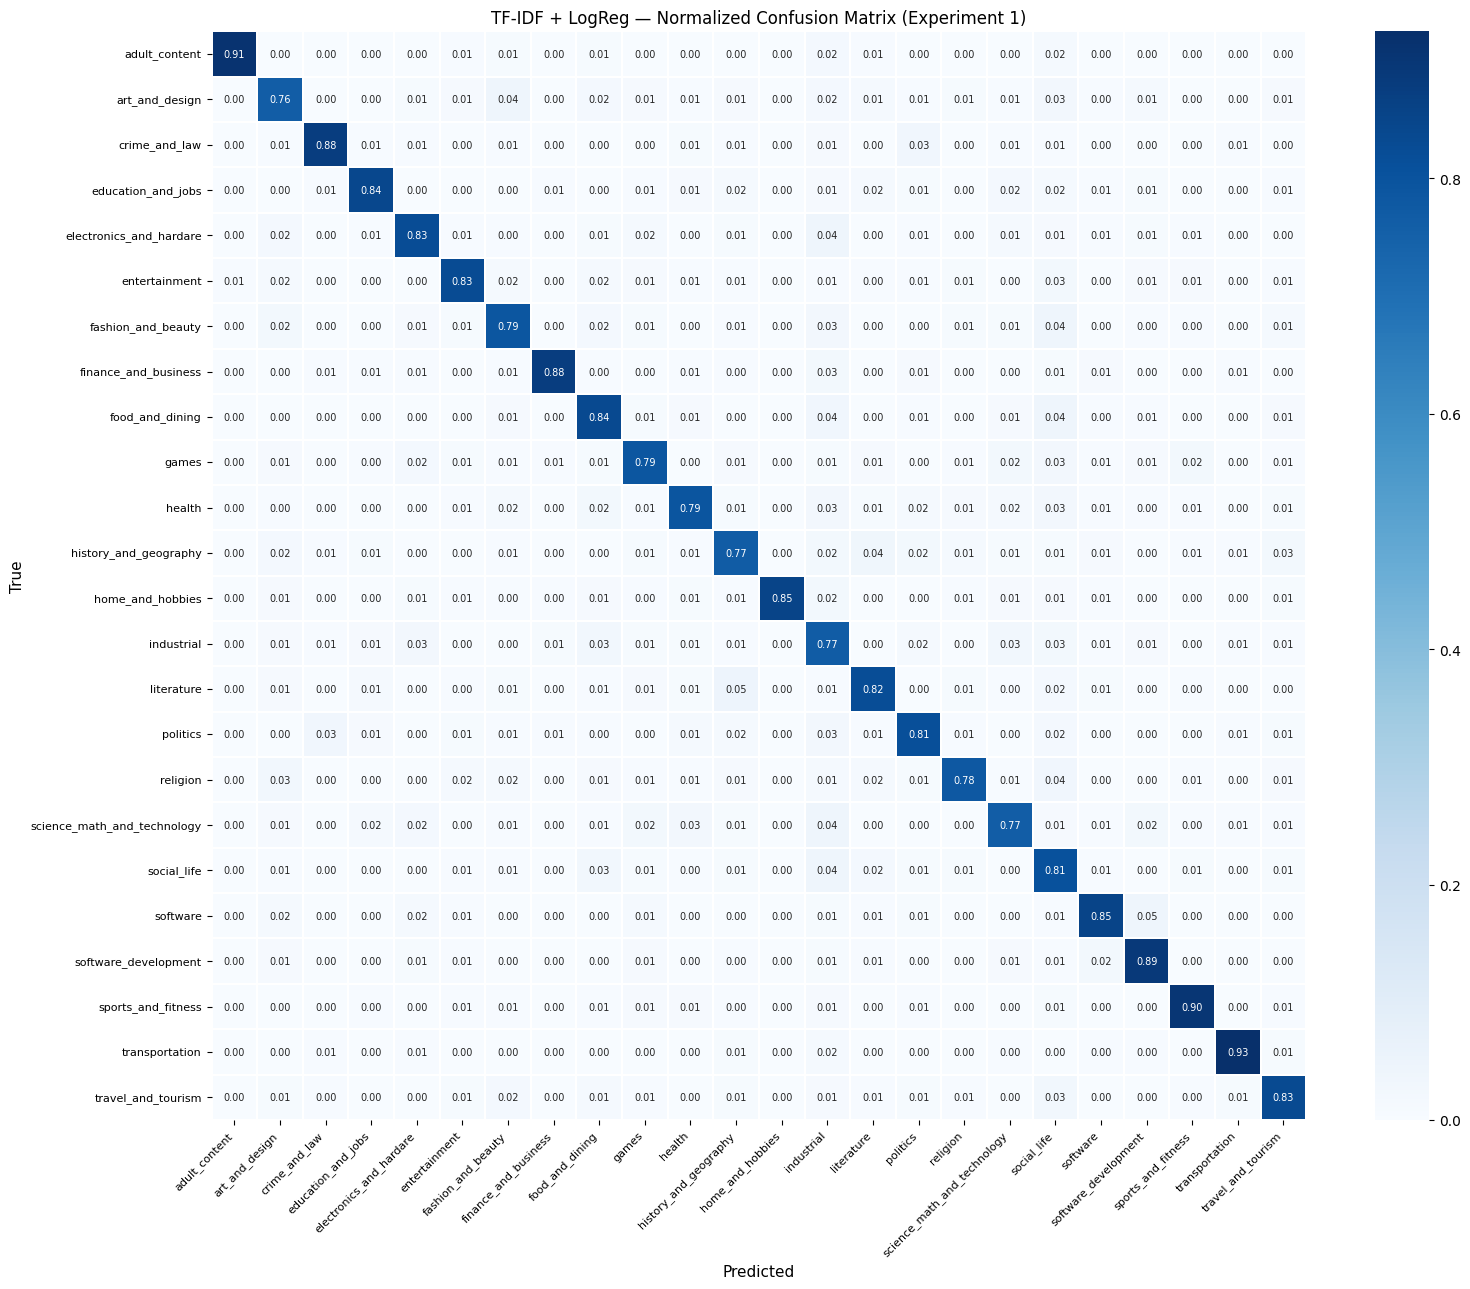

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

labels = sorted(subset["TOPIC"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Normalize by true class (row-wise) so each row sums to 1
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f",
    xticklabels=labels, yticklabels=labels,
    cmap="Blues", linewidths=0.3,
    ax=ax, annot_kws={"size": 7}
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title("TF-IDF + LogReg — Normalized Confusion Matrix (Experiment 1)", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("experiments/exp1_confusion_matrix.png", dpi=150)
plt.show()

---

In [6]:
import torch
print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0))   
print(torch.cuda.get_device_properties(0).total_memory / 1e9, "GB") 

True
NVIDIA GeForce RTX 4050 Laptop GPU
6.438780928 GB


---
## FastText Model

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 1. Label encoding ─────────────────────────────────────────────
le = LabelEncoder()
subset["label"] = le.fit_transform(subset["TOPIC"])
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    subset["DATA"].tolist(), subset["label"].tolist(),
    test_size=0.2, random_state=SEED, stratify=subset["label"]
)

# ── 2. Character n-gram hashing (no pretrained vocab needed) ──────
VOCAB_SIZE  = 300_000   # hashing trick bucket count
MAX_NGRAM   = 3         # use char 2-grams and 3-grams
MAX_WORDS   = 100       # truncate/pad document to this many words

def get_ngram_hashes(word, n):
    """Return hashed char n-gram ids for a single word."""
    padded = f"<{word}>"
    ngrams = [padded[i:i+n] for i in range(len(padded) - n + 1)]
    return [hash(ng) % VOCAB_SIZE for ng in ngrams]

def text_to_ids(text, max_words=MAX_WORDS):
    """Convert text to list of token+ngram hash ids, padded/truncated."""
    words = text.lower().split()[:max_words]
    ids = []
    for word in words:
        ids.append(hash(word) % VOCAB_SIZE)        # word unigram
        ids.extend(get_ngram_hashes(word, 2))      # char bigrams
        ids.extend(get_ngram_hashes(word, 3))      # char trigrams
    return ids

# ── 3. Dataset ────────────────────────────────────────────────────
class FastTextDataset(Dataset):
    def __init__(self, texts, labels, max_len=2000):
        self.labels = labels
        self.max_len = max_len
        print("Tokenizing...")
        self.ids = [text_to_ids(t) for t in texts]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ids = self.ids[idx][:self.max_len]
        return torch.tensor(ids, dtype=torch.long), self.labels[idx]

def collate_fn(batch):
    """Pad sequences in a batch to the same length."""
    seqs, labels = zip(*batch)
    max_len = max(len(s) for s in seqs)
    padded = torch.zeros(len(seqs), max_len, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s
    return padded, torch.tensor(labels, dtype=torch.long)

train_ds = FastTextDataset(X_train, y_train)
test_ds  = FastTextDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

# ── 4. Model ──────────────────────────────────────────────────────
class FastTextModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, mode="mean")  # dense
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        return self.classifier(embedded)

EMBED_DIM = 128
model = FastTextModel(VOCAB_SIZE, EMBED_DIM, num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")  # ~38.4M

# ── 5. Training ───────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3,
    steps_per_epoch=len(train_loader), epochs=10
)

def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return accuracy_score(all_labels, all_preds), all_preds, all_labels

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    t0 = time.time()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    acc, _, _ = evaluate(test_loader)
    print(f"Epoch {epoch+1:02d} | loss: {total_loss/len(train_loader):.4f} "
          f"| val_acc: {acc:.4f} | time: {time.time()-t0:.1f}s")

# ── 6. Final evaluation ───────────────────────────────────────────
acc, preds, labels = evaluate(test_loader)
print(f"\nFinal Accuracy: {acc:.4f}")
print(classification_report(labels, preds,
      target_names=le.classes_, digits=3))

Using device: cuda
Tokenizing...
Tokenizing...
Total parameters: 38,439,192
Epoch 01 | loss: 3.1458 | val_acc: 0.0991 | time: 41.0s
Epoch 02 | loss: 2.8647 | val_acc: 0.2894 | time: 51.7s
Epoch 03 | loss: 2.1416 | val_acc: 0.4995 | time: 49.1s
Epoch 04 | loss: 1.6321 | val_acc: 0.5850 | time: 53.1s
Epoch 05 | loss: 1.3803 | val_acc: 0.6308 | time: 41.1s
Epoch 06 | loss: 1.2318 | val_acc: 0.6607 | time: 25.0s
Epoch 07 | loss: 1.1390 | val_acc: 0.6720 | time: 24.1s
Epoch 08 | loss: 1.0824 | val_acc: 0.6797 | time: 24.6s
Epoch 09 | loss: 1.0551 | val_acc: 0.6832 | time: 23.3s
Epoch 10 | loss: 1.0459 | val_acc: 0.6827 | time: 25.3s

Final Accuracy: 0.6827
                             precision    recall  f1-score   support

              adult_content      0.755     0.913     0.826      1000
             art_and_design      0.470     0.523     0.495      1000
              crime_and_law      0.852     0.715     0.778      1000
         education_and_jobs      0.849     0.762     0.803     

---

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import time
import os

os.makedirs("experiments", exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 1. Load more data ─────────────────────────────────────────────
print("Loading larger subset...")
subset_large = load_stratified_subset("D:\IIT Gandhinagar\SRIP 26\Mayank Singh\dataset_10M.parquet", n_per_class=20000)
print(f"Total rows: {len(subset_large)}")
print(subset_large["TOPIC"].value_counts())

# ── 2. Label encoding ─────────────────────────────────────────────
le = LabelEncoder()
subset_large["label"] = le.fit_transform(subset_large["TOPIC"])
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    subset_large["DATA"].tolist(),
    subset_large["label"].tolist(),
    test_size=0.2, random_state=SEED,
    stratify=subset_large["label"]
)

# ── 3. Faster tokenization using vectorized hashing ───────────────
VOCAB_SIZE = 500_000   # larger bucket count reduces hash collisions
MAX_WORDS  = 150       # covers median text length across all classes

def text_to_ids_fast(text):
    """
    Vectorized n-gram hashing — avoids Python loops over characters.
    Uses word unigrams + bigrams (word-level) + char trigrams per word.
    """
    words = text.lower().split()[:MAX_WORDS]
    ids = []

    for i, word in enumerate(words):
        # Word unigram
        ids.append(hash(word) % VOCAB_SIZE)

        # Word bigram with next word
        if i < len(words) - 1:
            ids.append(hash(word + "_" + words[i+1]) % VOCAB_SIZE)

        # Char trigrams (most informative subword unit)
        padded = f"<{word}>"
        for j in range(len(padded) - 2):
            ids.append(hash(padded[j:j+3]) % VOCAB_SIZE)

    return ids if ids else [0]

# ── 4. Dataset ────────────────────────────────────────────────────
class FastTextDataset(Dataset):
    def __init__(self, texts, labels):
        self.labels = labels
        print(f"  Tokenizing {len(texts):,} texts...")
        t0 = time.time()
        self.ids = [text_to_ids_fast(t) for t in texts]
        print(f"  Done in {time.time()-t0:.1f}s")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.ids[idx], dtype=torch.long), self.labels[idx]

def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    max_len = lengths.max().item()
    padded = torch.zeros(len(seqs), max_len, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s
    return padded, torch.tensor(labels, dtype=torch.long), lengths

train_ds = FastTextDataset(X_train, y_train)
test_ds  = FastTextDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False,
                          collate_fn=collate_fn, num_workers=0,
                          pin_memory=True)

# ── 5. Improved model ─────────────────────────────────────────────
class FastTextV2(nn.Module):
    """
    Improvements over V1:
    - Larger embedding dim (256 vs 128)
    - Deeper classifier with batch norm for stable training
    - Passes sequence lengths to EmbeddingBag for correct mean pooling
      (ignores padding tokens in the average)
    """
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(
            vocab_size, embed_dim, mode="mean",
            padding_idx=0   # ignore padding in mean computation
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, lengths):
        # Build offsets for EmbeddingBag from lengths
        offsets = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        offsets[1:] = lengths[:-1].cumsum(0)

        # Flatten x and use offsets for correct per-sample mean
        embedded = self.embedding(x.view(-1), offsets)  # (batch, embed_dim)
        return self.classifier(embedded)

EMBED_DIM = 256
model = FastTextV2(VOCAB_SIZE, EMBED_DIM, num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# ── 6. Training with warmup + cosine decay ────────────────────────
EPOCHS = 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Cosine annealing — much gentler decay than OneCycleLR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # helps generalization

def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y, lengths in loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            preds = model(x, lengths).argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return accuracy_score(all_labels, all_preds), all_preds, all_labels

best_acc = 0
best_preds = None
patience_counter = 0
PATIENCE = 5

print("\nTraining...")
for epoch in range(EPOCHS):
    model.train()
    t0 = time.time()
    total_loss = 0

    for x, y, lengths in train_loader:
        x, y, lengths = x.to(device), y.to(device), lengths.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, lengths), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    val_acc, _, _ = evaluate(test_loader)
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch+1:02d} | loss: {total_loss/len(train_loader):.4f} "
          f"| val_acc: {val_acc:.4f} | lr: {lr:.6f} | time: {time.time()-t0:.1f}s")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_preds = None
        torch.save(model.state_dict(), "D:/IIT Gandhinagar/SRIP 26/Mayank Singh/experiments/fasttext_v2_best.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ── 7. Final evaluation using best checkpoint ─────────────────────
model.load_state_dict(torch.load("D:/IIT Gandhinagar/SRIP 26/Mayank Singh/experiments/fasttext_v2_best.pt"))
acc, preds, labels = evaluate(test_loader)
print(f"\nBest Accuracy: {acc:.4f}")
print(classification_report(labels, preds, target_names=le.classes_, digits=3))

<>:18: SyntaxWarning: invalid escape sequence '\I'
<>:18: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22960\323823762.py:18: SyntaxWarning: invalid escape sequence '\I'
  subset_large = load_stratified_subset("D:\IIT Gandhinagar\SRIP 26\Mayank Singh\dataset_10M.parquet", n_per_class=20000)


Using device: cuda
Loading larger subset...
Total rows: 480000
TOPIC
adult_content                  20000
art_and_design                 20000
crime_and_law                  20000
education_and_jobs             20000
electronics_and_hardare        20000
entertainment                  20000
fashion_and_beauty             20000
finance_and_business           20000
food_and_dining                20000
games                          20000
health                         20000
history_and_geography          20000
home_and_hobbies               20000
industrial                     20000
literature                     20000
politics                       20000
religion                       20000
science_math_and_technology    20000
social_life                    20000
software                       20000
software_development           20000
sports_and_fitness             20000
transportation                 20000
travel_and_tourism             20000
Name: count, dtype: int64
  Tokenizing 384,

RuntimeError: Parent directory experiments does not exist.

---
## Linear SVM

In [4]:

import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV

SEED = 42
np.random.seed(SEED)

# ── 1. Load same subset as LogReg experiment for fair comparison ──
# Use the 120K subset (5K per class) to keep it comparable to Exp 1
subset = load_stratified_subset(
    r"D:\IIT Gandhinagar\SRIP 26\Mayank Singh\dataset_10M.parquet",
    n_per_class=5000
)

X_train, X_test, y_train, y_test = train_test_split(
    subset["DATA"], subset["TOPIC"],
    test_size=0.2, random_state=SEED,
    stratify=subset["TOPIC"]
)

# ── 2. TF-IDF (same config as Exp 1 for fair comparison) ─────────
print("Fitting TF-IDF...")
t0 = time.time()
vectorizer = TfidfVectorizer(
    max_features=100_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=3,
    strip_accents="unicode",
    analyzer="word",
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f"TF-IDF done in {time.time()-t0:.1f}s | shape: {X_train_tfidf.shape}")

# ── 3. Linear SVM ─────────────────────────────────────────────────
print("\nTraining Linear SVM...")
t0 = time.time()
svm = LinearSVC(
    C=0.5,              # regularization — lower = stronger reg
    max_iter=2000,
    random_state=SEED,
    dual=True           # faster when n_samples > n_features
)
svm.fit(X_train_tfidf, y_train)
print(f"Training done in {time.time()-t0:.1f}s")

# ── 4. Evaluate ───────────────────────────────────────────────────
y_pred = svm.predict(X_test_tfidf)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=3))

# ── 5. Try different C values to find best regularization ─────────
print("\nTuning C parameter...")
for C in [0.1, 0.5, 1.0, 2.0, 5.0]:
    svm_c = LinearSVC(C=C, max_iter=2000, random_state=SEED, dual=True)
    svm_c.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, svm_c.predict(X_test_tfidf))
    print(f"  C={C:.1f} → accuracy: {acc:.4f}")

Fitting TF-IDF...
TF-IDF done in 778.1s | shape: (96000, 100000)

Training Linear SVM...
Training done in 43.0s

Accuracy: 0.8280
                             precision    recall  f1-score   support

              adult_content      0.984     0.917     0.949      1000
             art_and_design      0.767     0.762     0.765      1000
              crime_and_law      0.892     0.881     0.886      1000
         education_and_jobs      0.879     0.832     0.855      1000
    electronics_and_hardare      0.848     0.832     0.840      1000
              entertainment      0.868     0.822     0.844      1000
         fashion_and_beauty      0.780     0.796     0.788      1000
       finance_and_business      0.935     0.875     0.904      1000
            food_and_dining      0.765     0.850     0.805      1000
                      games      0.800     0.786     0.793      1000
                     health      0.823     0.795     0.809      1000
      history_and_geography      0.780   

---
## TextCNN

In [ ]:
# experiments/exp4_textcnn.py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 0. Data loading ───────────────────────────────────────────────
def load_stratified_subset(path, n_per_class=5000, seed=42):
    pf = pq.ParquetFile(path)
    chunks = []
    for batch in pf.iter_batches(batch_size=100_000, columns=["DATA", "TOPIC"]):
        chunk = batch.to_pandas()
        sampled_groups = []
        for topic, group in chunk.groupby("TOPIC"):
            n = min(len(group), 500)
            sampled_groups.append(group.sample(n, random_state=seed))
        chunks.append(pd.concat(sampled_groups, ignore_index=True))
    df = pd.concat(chunks, ignore_index=True)
    final_groups = []
    for topic, group in df.groupby("TOPIC"):
        n = min(len(group), n_per_class)
        final_groups.append(group.sample(n, random_state=seed))
    return pd.concat(final_groups, ignore_index=True)

# ── 1. Load data ──────────────────────────────────────────────────
print("Loading data...")
DATA_PATH = r"D:\IIT Gandhinagar\SRIP 26\Mayank Singh\dataset_10M.parquet"
subset = load_stratified_subset(DATA_PATH, n_per_class=20000)
print(f"Total rows: {len(subset)}")

# ── 2. Vocabulary builder ─────────────────────────────────────────
class Vocabulary:
    def __init__(self, max_size=50000):
        self.max_size  = max_size
        self.PAD_token = 0
        self.UNK_token = 1
        self.word2idx  = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word  = {0: "<PAD>", 1: "<UNK>"}

    def build(self, texts, min_freq=3):
        from collections import Counter
        print("  Building vocabulary...")
        counter = Counter()
        for text in texts:
            counter.update(text.lower().split())

        # Keep top (max_size - 2) most frequent words
        most_common = counter.most_common(self.max_size - 2)
        for word, freq in most_common:
            if freq >= min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

        print(f"  Vocabulary size: {len(self.word2idx):,}")
        return self

    def encode(self, text, max_len):
        tokens = text.lower().split()[:max_len]
        ids    = [self.word2idx.get(t, self.UNK_token) for t in tokens]
        # Pad or truncate to exactly max_len
        ids   += [self.PAD_token] * (max_len - len(ids))
        return ids

# ── 3. Label encode + vocab ───────────────────────────────────────
le = LabelEncoder()
subset["label"] = le.fit_transform(subset["TOPIC"])
num_classes     = len(le.classes_)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    subset["DATA"].tolist(),
    subset["label"].tolist(),
    test_size=0.2, random_state=SEED,
    stratify=subset["label"]
)

MAX_SEQ_LEN = 256   # covers majority of documents per EDA
vocab = Vocabulary(max_size=50000)
vocab.build(X_train_raw, min_freq=3)

# ── 4. Dataset ────────────────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.labels = labels
        self.max_len = max_len
        print(f"  Encoding {len(texts):,} texts...")
        t0 = time.time()
        self.ids = [vocab.encode(t, max_len) for t in texts]
        print(f"  Done in {time.time()-t0:.1f}s")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.ids[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_ds = TextDataset(X_train_raw, y_train, vocab, MAX_SEQ_LEN)
test_ds  = TextDataset(X_test_raw,  y_test,  vocab, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=0, pin_memory=True)

# ── 5. TextCNN architecture ───────────────────────────────────────
class TextCNN(nn.Module):
    """
    Kim (2014) TextCNN built from scratch.

    Architecture:
      Embedding → Parallel Conv1d with multiple kernel sizes
      → ReLU → MaxPool over time → Concat → Dropout → Linear

    Each kernel size acts like an n-gram detector:
      kernel=2 detects bigram patterns
      kernel=3 detects trigram patterns
      kernel=4 detects 4-gram patterns
      kernel=5 detects 5-gram patterns
    """
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=128, kernel_sizes=(2, 3, 4, 5),
                 dropout=0.5, pad_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=pad_idx
        )

        # One Conv1d per kernel size — parallel n-gram detectors
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout  = nn.Dropout(dropout)
        self.fc       = nn.Linear(num_filters * len(kernel_sizes), num_classes)

        self._init_weights()

    def _init_weights(self):
        # Xavier init for conv and linear layers
        for conv in self.convs:
            nn.init.xavier_uniform_(conv.weight)
            nn.init.zeros_(conv.bias)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)              # (batch, seq_len, embed_dim)
        embedded = self.dropout(embedded)

        # Conv1d expects (batch, channels, seq_len)
        embedded = embedded.permute(0, 2, 1)      # (batch, embed_dim, seq_len)

        # Apply each conv + ReLU + global max pool
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))        # (batch, num_filters, seq_len - k + 1)
            c = c.max(dim=2).values               # (batch, num_filters) — max over time
            pooled.append(c)

        # Concatenate all filter outputs
        cat = torch.cat(pooled, dim=1)            # (batch, num_filters * len(kernels))
        cat = self.dropout(cat)
        return self.fc(cat)                       # (batch, num_classes)

# ── 6. Instantiate model ──────────────────────────────────────────
model = TextCNN(
    vocab_size   = len(vocab.word2idx),
    embed_dim    = 128,
    num_classes  = num_classes,
    num_filters  = 128,
    kernel_sizes = (2, 3, 4, 5),
    dropout      = 0.5,
    pad_idx      = vocab.PAD_token
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# ── 7. Training setup ─────────────────────────────────────────────
EPOCHS    = 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)

# ── 8. Evaluation ─────────────────────────────────────────────────
def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return accuracy_score(all_labels, all_preds), all_preds, all_labels

# ── 9. Training loop ──────────────────────────────────────────────
best_acc        = 0
patience_counter = 0
PATIENCE        = 5

print("\nTraining TextCNN...")
for epoch in range(EPOCHS):
    model.train()
    t0         = time.time()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    val_acc, _, _ = evaluate(test_loader)
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch+1:02d} | loss: {total_loss/len(train_loader):.4f} "
          f"| val_acc: {val_acc:.4f} | lr: {lr:.6f} | time: {time.time()-t0:.1f}s")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "vocab":       vocab.word2idx,
            "label_enc":   le.classes_,
            "config": {
                "vocab_size":   len(vocab.word2idx),
                "embed_dim":    128,
                "num_classes":  num_classes,
                "num_filters":  128,
                "kernel_sizes": (2, 3, 4, 5),
            }
        }, "experiments/textcnn_best.pt")
        patience_counter = 0
        print(f"          ↑ best model saved (acc={best_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ── 10. Final evaluation ──────────────────────────────────────────
checkpoint = torch.load("experiments/textcnn_best.pt")
model.load_state_dict(checkpoint["model_state"])
acc, preds, labels = evaluate(test_loader)

print(f"\nFinal Accuracy: {acc:.4f}")
print(classification_report(labels, preds,
      target_names=le.classes_, digits=3))